In [3]:
!git clone "https://github.com/thaortrinh/pm25-hcmc.git"

fatal: destination path 'pm25-hcmc' already exists and is not an empty directory.


In [4]:
!pip install catboost optuna optuna-integration -q

## 🌟 PM2.5 MIMO Forecasting: t+1 → t+6

Notebook này chuyển từ **single-step (t+1)** sang **MIMO — Multi-Input Multi-Output**,  
dự báo đồng thời 6 bước thời gian tương lai: `t+1h, t+2h, ..., t+6h`.

**Kiến trúc MIMO:**
- 1 lần fit → output shape `(n_samples, 6)`
- Tránh error propagation của recursive forecasting
- CatBoost dùng `loss_function='MultiRMSE'` native
- Các model khác dùng `MultiOutputRegressor` wrapper

**Feature engineering** giữ nguyên từ `Model_Training.ipynb`, chỉ thay phần target và training.

### 0. Imports & Config

In [5]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from pathlib import Path

from sklearn.multioutput import MultiOutputRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')

# ── Global config ──────────────────────────────────────────────────────────────
HORIZON      = 6                                          # số bước dự báo
TARGET_COLS  = [f'target_h{h}' for h in range(1, HORIZON + 1)]  # ['target_h1'...'target_h6']
RANDOM_STATE = 42
CAT_FEATURES = ['time_of_the_day']                        # categorical feature cho CatBoost

print(f'HORIZON = {HORIZON}')
print(f'TARGET_COLS = {TARGET_COLS}')

HORIZON = 6
TARGET_COLS = ['target_h1', 'target_h2', 'target_h3', 'target_h4', 'target_h5', 'target_h6']


### 1. Feature Engineering

In [6]:
# Load dataset
pm25_df = pd.read_csv('./pm25-hcmc/data/processed/pm25_weather_merged.csv')
pm25_df['datetime'] = pd.to_datetime(pm25_df['datetime'])
pm25_df = pm25_df.set_index('datetime').sort_index()
pm25_df.index = pm25_df.index.tz_localize(None) if pm25_df.index.tz is None \
                else pm25_df.index.tz_convert(None)

# Drop cột không cần
pm25_df.drop(columns=['is_pm25_missing'], inplace=True, errors='ignore')

# ── Season ────────────────────────────────────────────────────────────────────
def get_season(month):
    if 3 <= month <= 5:   return 'Spring'
    elif 6 <= month <= 8: return 'Summer'
    elif 9 <= month <= 11: return 'Autumn'
    else:                  return 'Winter'
pm25_df['Season'] = pm25_df['month'].apply(get_season)

# ── Time of day ───────────────────────────────────────────────────────────────
def get_time_of_day(hour):
    if 5 <= hour < 12:   return 'Morning'
    elif 12 <= hour < 17: return 'Noon'
    elif 17 <= hour < 21: return 'Evening'
    else:                  return 'Night'
pm25_df['time_of_the_day'] = pm25_df['hour'].apply(get_time_of_day)

# ── Rush hour ─────────────────────────────────────────────────────────────────
current_hour = pm25_df.index.hour
pm25_df['rush_hour_weekday'] = (
    (pm25_df['is_weekend'] == 0) &
    (
        ((current_hour >= 6)  & (current_hour <= 9)) |
        ((current_hour >= 16) & (current_hour <= 19))
    )
).astype(int)

# ── Monday start ──────────────────────────────────────────────────────────────
pm25_df['Monday_start'] = ((pm25_df['weekday'] == 0) & (pm25_df['hour'] == 0)).astype(int)

# ── Autoregressive lags ───────────────────────────────────────────────────────
pm25_df['pm25_avg_lag1']  = pm25_df['pm25_avg'].shift(1)
pm25_df['pm25_avg_lag6']  = pm25_df['pm25_avg'].shift(6)
pm25_df['pm25_avg_lag24'] = pm25_df['pm25_avg'].shift(24)
pm25_df['temperature_2m_lag1'] = pm25_df['temperature_2m'].shift(1)

# ── Rolling statistics (shift(1) trước để tránh leakage) ─────────────────────
_s = pm25_df['pm25_avg'].shift(1)
pm25_df['pm25_avg_rolling_mean_3h']  = _s.rolling(3).mean()
pm25_df['pm25_avg_rolling_mean_6h']  = _s.rolling(6).mean()
pm25_df['pm25_avg_rolling_mean_12h'] = _s.rolling(12).mean()
pm25_df['temperature_2m_rolling_mean_3h'] = pm25_df['temperature_2m'].shift(1).rolling(3).mean()

# ── Cyclical time features ────────────────────────────────────────────────────
pm25_df['day_of_year'] = pm25_df.index.dayofyear
pm25_df['day_of_year_sin'] = np.sin(2 * np.pi * pm25_df['day_of_year'] / 366)
pm25_df['day_of_year_cos'] = np.cos(2 * np.pi * pm25_df['day_of_year'] / 366)

# ── Special holidays ──────────────────────────────────────────────────────────
special_holiday_dates = [
    date(2025, 1, 28), date(2025, 1, 29), date(2025, 1, 30), date(2025, 1, 31),
    date(2025, 2, 12), date(2025, 4, 30), date(2025, 6, 1), date(2025, 8, 8),
    date(2025, 9, 2),
    date(2026, 2, 16), date(2026, 2, 17), date(2026, 2, 18), date(2026, 2, 19),
    date(2026, 3, 3)
]
dates_series = pd.Series(pm25_df.index.date, index=pm25_df.index)
pm25_df['special_holidays'] = dates_series.isin(special_holiday_dates).astype(int)

# ── Derived physics features ──────────────────────────────────────────────────
pm25_df['pm25_avg_diff_1h']   = pm25_df['pm25_avg'].diff(1)
pm25_df['ventilation_coeff']  = pm25_df['wind_speed_10m'] * pm25_df['boundary_layer_height']
pm25_df['wind_magnitude']     = np.sqrt(pm25_df['wind_u']**2 + pm25_df['wind_v']**2)
pm25_df['wind_stagnation_index'] = 1 / (pm25_df['wind_speed_10m'] + 0.1)
pm25_df['is_stagnant_humid']  = ((pm25_df['relative_humidity_2m'] > 80) & (pm25_df['wind_speed_10m'] < 2)).astype(int)
pm25_df['dew_point']          = pm25_df['temperature_2m'] - (100 - pm25_df['relative_humidity_2m']) / 5
pm25_df['pm25_delta']         = pm25_df['pm25_avg'].shift(1) - pm25_df['pm25_avg'].shift(2)
pm25_df['pm25_acceleration']  = pm25_df['pm25_avg'].diff(1).diff(1)

print('Shape sau feature engineering:', pm25_df.shape)
display(pm25_df.head())

Shape sau feature engineering: (10409, 48)


,pm25_avg,pm25_min,pm25_max,pm25_median,coverage_pct,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,...,day_of_year_cos,special_holidays,pm25_avg_diff_1h,ventilation_coeff,wind_magnitude,wind_stagnation_index,is_stagnant_humid,dew_point,pm25_delta,pm25_acceleration
datetime,,,,,,,,,,,,,,,,,,,,,
2024-11-19 10:00:00,29.139999,29.139999,29.139999,29.139999,100.0,32.0,55,0.0,1.57,59,...,0.751132,0,NaN,1428.70,1.57,0.598802,0,23.0,NaN,NaN
2024-11-19 11:00:00,29.150000,29.150000,29.150000,29.150000,100.0,30.9,59,0.1,0.29,211,...,0.751132,0,0.010001,43.50,0.29,2.564103,0,22.7,NaN,NaN
2024-11-19 12:00:00,31.783333,31.783333,31.783333,31.783333,100.0,29.3,68,0.0,1.37,204,...,0.751132,0,2.633333,335.65,1.37,0.680272,0,22.9,0.010001,2.623332
2024-11-19 13:00:00,30.950000,30.950000,30.950000,30.950000,100.0,26.6,77,0.2,0.78,105,...,0.751132,0,-0.833333,74.10,0.78,1.136364,0,22.0,2.633333,-3.466666
2024-11-19 14:00:00,30.216667,30.216667,30.216667,30.216667,100.0,26.6,79,0.1,1.10,309,...,0.751132,0,-0.733333,93.50,1.10,0.833333,0,22.4,-0.833333,0.100000


### 2. Tạo MIMO Targets (t+1 → t+6)

In [7]:
# Tạo 6 cột target bằng shift âm
# Tại thời điểm t: target_h1 = pm25(t+1), target_h2 = pm25(t+2), ...
for h in range(1, HORIZON + 1):
    pm25_df[f'target_h{h}'] = pm25_df['pm25_avg'].shift(-h)

print('Target columns created:')
print(TARGET_COLS)
print(f'\nShape: {pm25_df.shape}')

Target columns created:
['target_h1', 'target_h2', 'target_h3', 'target_h4', 'target_h5', 'target_h6']

Shape: (10409, 54)


### 3. Preprocessing

In [8]:
pm25_df_processed = pm25_df.copy()

# Drop cột thô không cần (đã có FE thay thế)
columns_to_drop = [
    'day', 'month', 'hour', 'weekday',
    'pm25_max', 'pm25_min', 'pm25_median',
    'day_of_year', 'date', 'year',
    'boundary_layer_height', 'temperature_2m',
    'Season'  # sẽ dùng time_of_the_day thay thế
]
columns_to_drop = [c for c in columns_to_drop if c in pm25_df_processed.columns]
pm25_df_processed.drop(columns=columns_to_drop, inplace=True)

# Drop NaN (từ lag/rolling đầu chuỗi + target shift âm cuối chuỗi)
print('NaN trước dropna:', pm25_df_processed.isnull().sum().sum())
pm25_df_processed.dropna(inplace=True)
print('NaN sau dropna: ', pm25_df_processed.isnull().sum().sum())
print('Shape sau dropna:', pm25_df_processed.shape)

print('\nColumns cuối cùng:')
print(pm25_df_processed.columns.tolist())

NaN trước dropna: 82
NaN sau dropna:  0
Shape sau dropna: (10379, 42)

Columns cuối cùng:
['pm25_avg', 'coverage_pct', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'wind_direction_10m', 'surface_pressure', 'wind_u', 'wind_v', 'is_weekend', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'time_of_the_day', 'rush_hour_weekday', 'Monday_start', 'pm25_avg_lag1', 'pm25_avg_lag6', 'pm25_avg_lag24', 'temperature_2m_lag1', 'pm25_avg_rolling_mean_3h', 'pm25_avg_rolling_mean_6h', 'pm25_avg_rolling_mean_12h', 'temperature_2m_rolling_mean_3h', 'day_of_year_sin', 'day_of_year_cos', 'special_holidays', 'pm25_avg_diff_1h', 'ventilation_coeff', 'wind_magnitude', 'wind_stagnation_index', 'is_stagnant_humid', 'dew_point', 'pm25_delta', 'pm25_acceleration', 'target_h1', 'target_h2', 'target_h3', 'target_h4', 'target_h5', 'target_h6']


### 4. Correlation Analysis

Correlation với target_h1 (top 15):


pm25_avg                     0.872553
pm25_avg_lag1                0.725146
pm25_avg_rolling_mean_3h     0.651617
pm25_avg_rolling_mean_6h     0.559431
pm25_avg_rolling_mean_12h    0.458002
pm25_avg_lag24               0.375517
day_of_year_cos              0.314503
month_cos                    0.307819
pm25_avg_lag6                0.295758
pm25_avg_diff_1h             0.292023
pm25_delta                   0.237894
surface_pressure             0.226647
hour_cos                     0.218735
wind_stagnation_index        0.210532
is_stagnant_humid            0.123248
Name: target_h1, dtype: float64

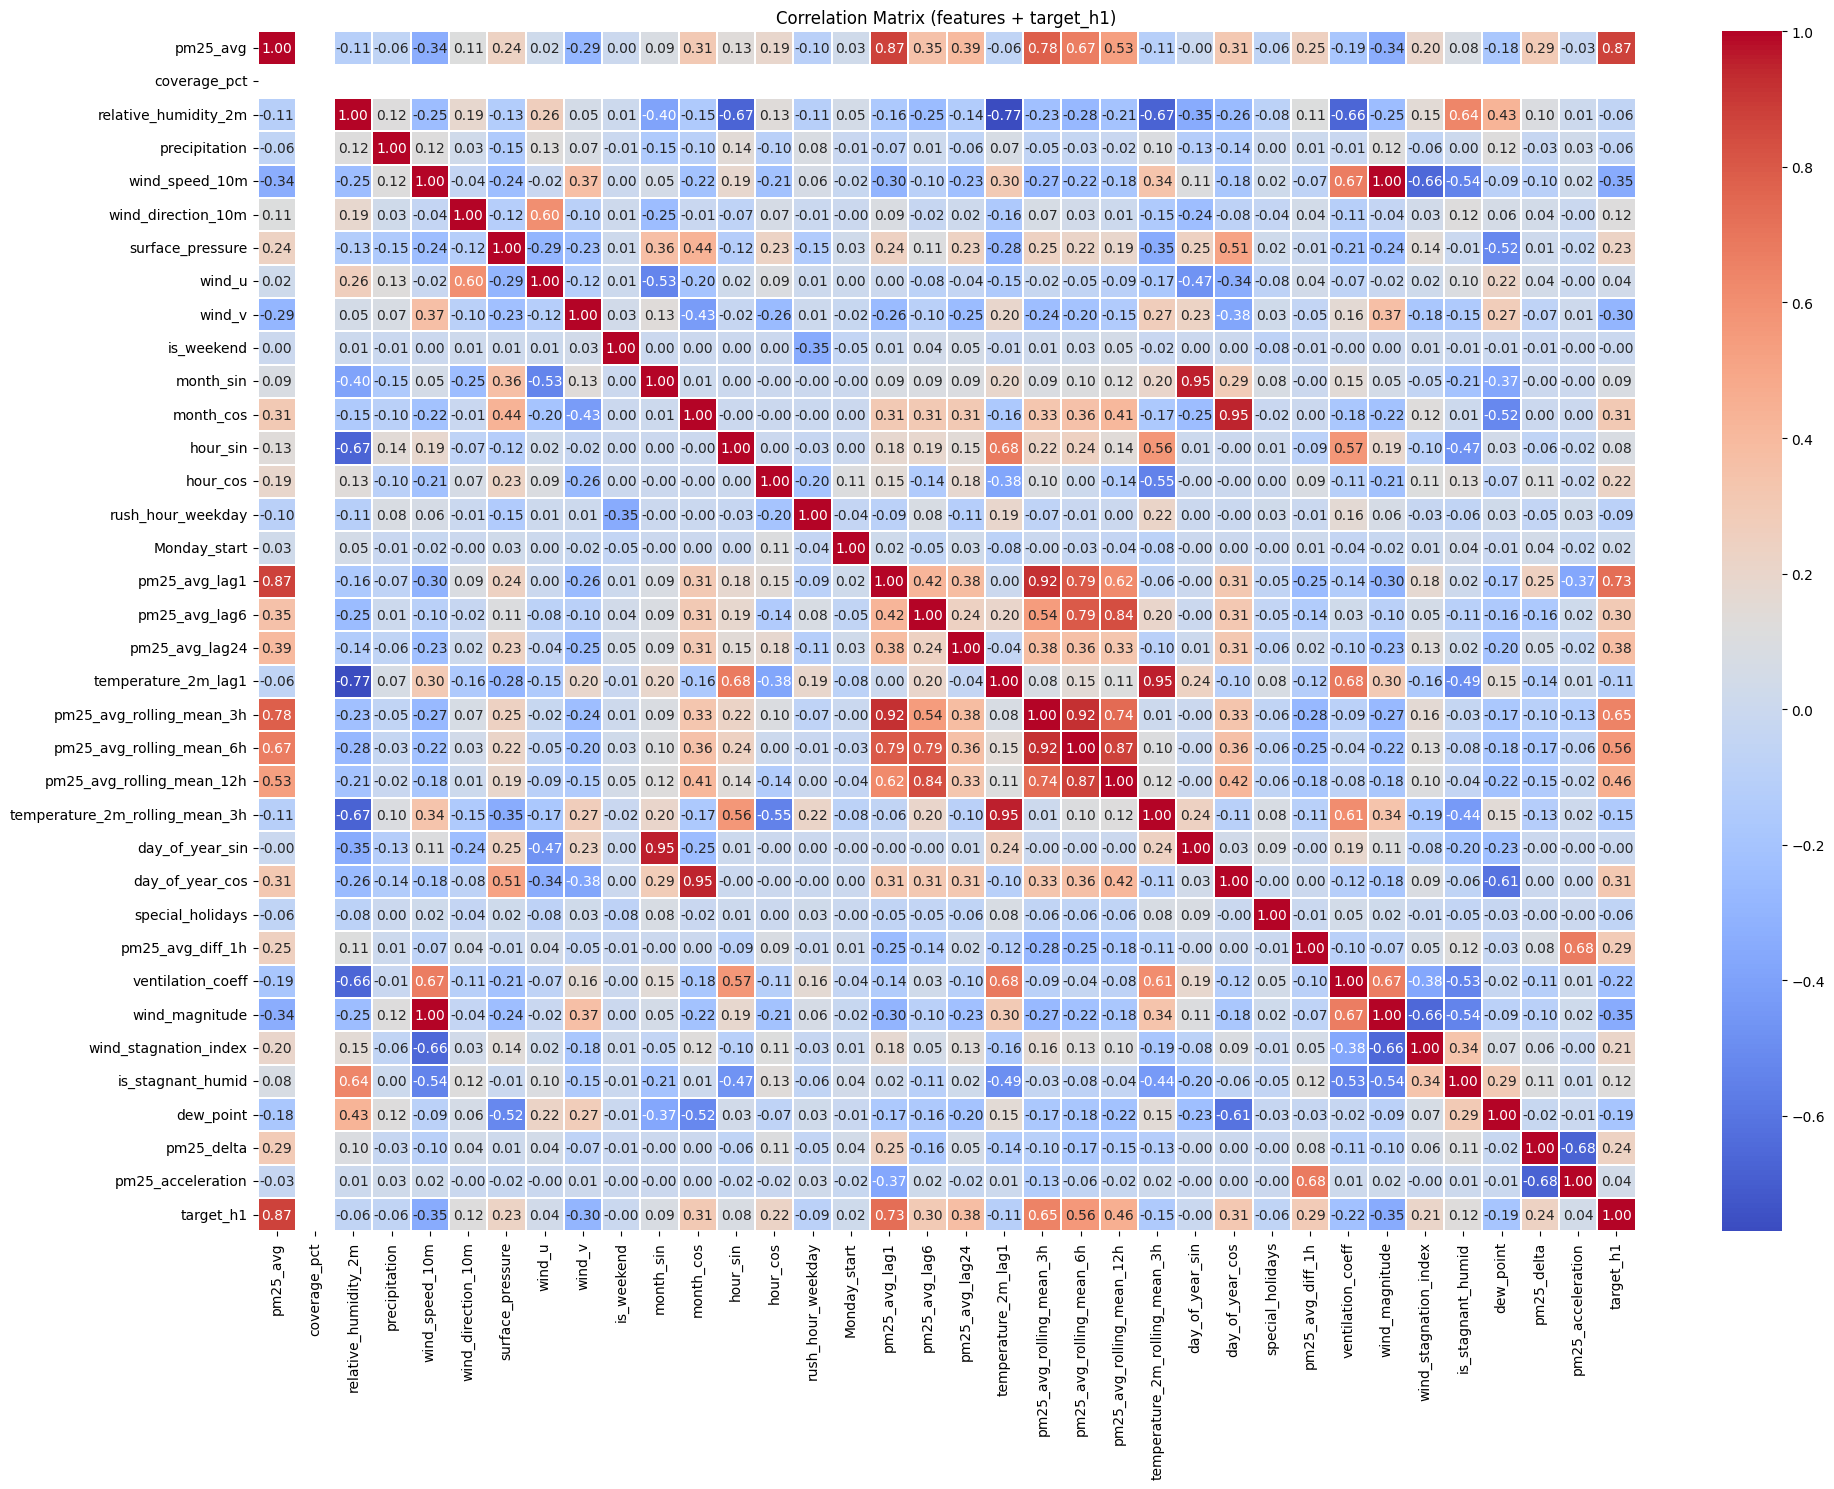

In [9]:
# Correlation với target_h1 (đại diện)
corr = pm25_df_processed.select_dtypes(include=np.number).corr()
print('Correlation với target_h1 (top 15):')
display(corr['target_h1'].drop(TARGET_COLS, errors='ignore').sort_values(ascending=False).head(15))

# Heatmap
plt.figure(figsize=(20, 15))
numeric_cols_plot = [c for c in pm25_df_processed.columns if c not in TARGET_COLS[1:]]
sns.heatmap(
    pm25_df_processed[numeric_cols_plot].select_dtypes(include=np.number).corr(),
    cmap='coolwarm', fmt='.2f', linewidths=.3, annot=True
)
plt.title('Correlation Matrix (features + target_h1)')
plt.tight_layout()
plt.show()

### 5. Định nghĩa X, Y & Train/Valid/Test Split

In [10]:
# Feature columns = tất cả trừ target
FEATURE_COLS = [c for c in pm25_df_processed.columns if c not in TARGET_COLS]

X = pm25_df_processed[FEATURE_COLS].copy()
Y = pm25_df_processed[TARGET_COLS].copy()   # shape (n, 6)

print(f'X shape: {X.shape}')
print(f'Y shape: {Y.shape}  ← MIMO: 6 outputs per sample')
print(f'\nFeatures ({len(FEATURE_COLS)}):')
print(FEATURE_COLS)

# ── Chronological split: 70% train / 15% valid / 15% test ────────────────────
n = len(X)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

X_train, Y_train = X.iloc[:train_end],        Y.iloc[:train_end]
X_valid, Y_valid = X.iloc[train_end:valid_end], Y.iloc[train_end:valid_end]
X_test,  Y_test  = X.iloc[valid_end:],         Y.iloc[valid_end:]

print(f'\nTrain : {len(X_train):,} rows  ({X_train.index.min()} → {X_train.index.max()})')
print(f'Valid : {len(X_valid):,} rows  ({X_valid.index.min()} → {X_valid.index.max()})')
print(f'Test  : {len(X_test):,} rows  ({X_test.index.min()} → {X_test.index.max()})')

X shape: (10379, 36)
Y shape: (10379, 6)  ← MIMO: 6 outputs per sample

Features (36):
['pm25_avg', 'coverage_pct', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'wind_direction_10m', 'surface_pressure', 'wind_u', 'wind_v', 'is_weekend', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'time_of_the_day', 'rush_hour_weekday', 'Monday_start', 'pm25_avg_lag1', 'pm25_avg_lag6', 'pm25_avg_lag24', 'temperature_2m_lag1', 'pm25_avg_rolling_mean_3h', 'pm25_avg_rolling_mean_6h', 'pm25_avg_rolling_mean_12h', 'temperature_2m_rolling_mean_3h', 'day_of_year_sin', 'day_of_year_cos', 'special_holidays', 'pm25_avg_diff_1h', 'ventilation_coeff', 'wind_magnitude', 'wind_stagnation_index', 'is_stagnant_humid', 'dew_point', 'pm25_delta', 'pm25_acceleration']

Train : 7,265 rows  (2024-11-20 10:00:00 → 2025-11-11 18:00:00)
Valid : 1,557 rows  (2025-11-11 19:00:00 → 2026-01-16 20:00:00)
Test  : 1,557 rows  (2026-01-16 21:00:00 → 2026-03-22 17:00:00)


### 6. Helper Functions

In [11]:
def build_preprocessor(X_df, categorical_cols=None):
    """ColumnTransformer: OneHot cho cat, StandardScaler cho numeric."""
    categorical_cols = categorical_cols or []
    numeric_cols = [c for c in X_df.columns if c not in categorical_cols]
    transformers = [('num', StandardScaler(), numeric_cols)]
    if categorical_cols:
        transformers.insert(0, ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols))
    return ColumnTransformer(transformers=transformers)


def evaluate_mimo(Y_true, Y_pred, horizon=HORIZON):
    """Tính MAE, RMSE, R2 per horizon + overall average."""
    Y_true = np.array(Y_true)
    Y_pred = np.array(Y_pred)
    rows = []
    for h in range(horizon):
        yt, yp = Y_true[:, h], Y_pred[:, h]
        rows.append({
            'Horizon': f't+{h+1}h',
            'MAE' : round(mean_absolute_error(yt, yp), 3),
            'RMSE': round(np.sqrt(mean_squared_error(yt, yp)), 3),
            'R2'  : round(r2_score(yt, yp), 4)
        })
    rows.append({
        'Horizon': 'AVERAGE',
        'MAE' : round(mean_absolute_error(Y_true.ravel(), Y_pred.ravel()), 3),
        'RMSE': round(np.sqrt(mean_squared_error(Y_true.ravel(), Y_pred.ravel())), 3),
        'R2'  : round(np.mean([r2_score(Y_true[:, h], Y_pred[:, h]) for h in range(horizon)]), 4)
    })
    return pd.DataFrame(rows)


def get_models():
    return {
        'Linear Regression': LinearRegression(),
        'KNN': MultiOutputRegressor(
            KNeighborsRegressor(n_neighbors=5), n_jobs=-1
        ),
        'Random Forest': RandomForestRegressor(
            n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
        ),
        'XGBoost': MultiOutputRegressor(
            XGBRegressor(n_estimators=100, learning_rate=0.1,
                         random_state=RANDOM_STATE, verbosity=0),
            n_jobs=-1
        ),
        'CatBoost': CatBoostRegressor(
            loss_function='MultiRMSE',
            eval_metric='MultiRMSE',
            iterations=500,        # ← giảm từ 2000 xuống 500
            learning_rate=0.05,    # ← tăng lr để bù iterations ít hơn
            depth=5,               # ← giảm từ 6 xuống 5
            l2_leaf_reg=5,
            random_strength=1,
            subsample=0.8,
            bootstrap_type='Bernoulli',
            od_type='Iter',
            od_wait=50,            # ← giảm từ 100 xuống 50
            verbose=100,
            random_seed=RANDOM_STATE
        )
    }

print('Helper functions defined ✓')

Helper functions defined ✓


### 7. Training — MIMO (t+1 → t+6)

In [12]:
# ── Preprocessor (chỉ dùng cho non-CatBoost) ──────────────────────────────────
cat_cols_present = [c for c in CAT_FEATURES if c in X_train.columns]
preprocessor = build_preprocessor(X_train, categorical_cols=cat_cols_present)
X_train_proc = preprocessor.fit_transform(X_train)
X_valid_proc = preprocessor.transform(X_valid)
X_test_proc  = preprocessor.transform(X_test)

print(f'Feature shape sau preprocessing: {X_train_proc.shape}')

models   = get_models()
results  = {}

for name, model in models.items():
    print(f'\n[MIMO] Training {name}...')

    if name == 'CatBoost':
        # CatBoost hỗ trợ MultiRMSE natively — truyền Y dạng DataFrame (n, 6)
        model.fit(
            X_train, Y_train,
            cat_features=cat_cols_present if cat_cols_present else None,
            eval_set=(X_valid, Y_valid),
            use_best_model=True
        )
        Y_pred = model.predict(X_test)   # shape (n, 6)
    else:
        # Các model còn lại dùng MultiOutputRegressor wrapper
        model.fit(X_train_proc, Y_train)
        Y_pred = model.predict(X_test_proc)

    df_metrics = evaluate_mimo(Y_test.values, Y_pred)
    df_metrics.insert(0, 'Model', name)
    results[name] = {'metrics': df_metrics, 'model': model, 'Y_pred': Y_pred}

    avg = df_metrics[df_metrics['Horizon'] == 'AVERAGE'].iloc[0]
    print(f'  → AVERAGE  MAE={avg["MAE"]}  RMSE={avg["RMSE"]}  R2={avg["R2"]}')

print('\n✅ Training hoàn tất!')

Feature shape sau preprocessing: (7265, 38)

[MIMO] Training Linear Regression...
  → AVERAGE  MAE=8.977  RMSE=12.571  R2=0.4061

[MIMO] Training KNN...
  → AVERAGE  MAE=9.606  RMSE=13.673  R2=0.2974

[MIMO] Training Random Forest...
  → AVERAGE  MAE=8.09  RMSE=12.001  R2=0.4587

[MIMO] Training XGBoost...
  → AVERAGE  MAE=8.239  RMSE=12.258  R2=0.4353

[MIMO] Training CatBoost...
0:	learn: 39.1032732	test: 55.3204327	best: 55.3204327 (0)	total: 134ms	remaining: 1m 7s
100:	learn: 27.8091730	test: 38.7096724	best: 38.7096724 (100)	total: 4.95s	remaining: 19.6s
200:	learn: 26.4387716	test: 38.4917550	best: 38.4641120 (156)	total: 9.74s	remaining: 14.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 38.46411198
bestIteration = 156

Shrink model to first 157 iterations.
  → AVERAGE  MAE=7.985  RMSE=11.628  R2=0.4918

✅ Training hoàn tất!


### 8. Kết quả — Overall (average 6 horizons)

In [13]:
df_summary = pd.concat(
    [v['metrics'][v['metrics']['Horizon'] == 'AVERAGE'] for v in results.values()],
    ignore_index=True
).sort_values('R2', ascending=False)

print('=== MIMO — Overall (average across 6 horizons) ===')
display(df_summary)

=== MIMO — Overall (average across 6 horizons) ===


,Model,Horizon,MAE,RMSE,R2
4,CatBoost,AVERAGE,7.985,11.628,0.4918
2,Random Forest,AVERAGE,8.090,12.001,0.4587
3,XGBoost,AVERAGE,8.239,12.258,0.4353
0,Linear Regression,AVERAGE,8.977,12.571,0.4061
1,KNN,AVERAGE,9.606,13.673,0.2974


### 9. Kết quả — Per Horizon

In [17]:
df_detail = pd.concat(
    [v['metrics'][v['metrics']['Horizon'] != 'AVERAGE'] for v in results.values()],
    ignore_index=True
)

horizon_order = [f't+{h}h' for h in range(1, HORIZON + 1)]

print('=== MAE per horizon ===')
display(df_detail.pivot_table(index='Model', columns='Horizon', values='MAE', aggfunc='first')
        .reindex(columns=horizon_order))

print('=== RMSE per horizon ===')
display(df_detail.pivot_table(index='Model', columns='Horizon', values='RMSE', aggfunc='first')
        .reindex(columns=horizon_order))

print('\n=== R2 per horizon ===')
display(df_detail.pivot_table(index='Model', columns='Horizon', values='R2', aggfunc='first')
        .reindex(columns=horizon_order))

=== MAE per horizon ===


Horizon,t+1h,t+2h,t+3h,t+4h,t+5h,t+6h
Model,,,,,,
CatBoost,4.707,6.813,7.937,8.828,9.493,10.131
KNN,7.160,8.623,9.626,10.336,10.807,11.083
Linear Regression,4.997,7.599,9.003,10.099,10.829,11.331
Random Forest,4.823,7.066,8.198,8.961,9.519,9.971
XGBoost,4.711,7.049,8.256,9.199,9.913,10.308


=== RMSE per horizon ===


Horizon,t+1h,t+2h,t+3h,t+4h,t+5h,t+6h
Model,,,,,,
CatBoost,7.900,10.374,11.550,12.389,13.015,13.602
KNN,10.581,12.409,13.533,14.442,15.011,15.450
Linear Regression,8.504,11.160,12.499,13.463,14.134,14.633
Random Forest,8.098,10.859,12.119,12.811,13.391,13.798
XGBoost,8.232,10.856,12.188,13.023,13.935,14.270



=== R2 per horizon ===


Horizon,t+1h,t+2h,t+3h,t+4h,t+5h,t+6h
Model,,,,,,
CatBoost,0.7653,0.5956,0.4990,0.4235,0.3635,0.3042
KNN,0.5790,0.4213,0.3121,0.2167,0.1532,0.1022
Linear Regression,0.7280,0.5320,0.4132,0.3192,0.2493,0.1947
Random Forest,0.7534,0.5569,0.4483,0.3836,0.3261,0.2839
XGBoost,0.7451,0.5571,0.4420,0.3630,0.2703,0.2342


In [16]:
# @title Bảng so sánh Metrics chi tiết theo từng Horizon (Lag)
from IPython.display import display, HTML
import pandas as pd

# 1. Tập hợp dữ liệu chi tiết
df_detail = pd.concat(
    [v['metrics'][v['metrics']['Horizon'] != 'AVERAGE'] for v in results.values()],
    ignore_index=True
)

# 2. Xác định thứ tự cột (Horizon Order)
horizon_order = [f't+{h}h' for h in range(1, HORIZON + 1)]

# 3. Danh sách các metrics và logic định dạng
# (Tên metric, Tên hiển thị, Càng thấp càng tốt?)
metrics_config = [
    ('MAE', '=== MAE PER HORIZON (Lower is Better) ===', True),
    ('RMSE', '=== RMSE PER HORIZON (Lower is Better) ===', True),
    ('R2', '=== R2 SCORE PER HORIZON (Higher is Better) ===', False)
]

# Kiểm tra xem cột R2 trong dữ liệu thực tế tên là gì (R2 hay R2 Score)
actual_r2_name = 'R2' if 'R2' in df_detail.columns else 'R2 Score'
metrics_config[2] = (actual_r2_name, metrics_config[2][1], metrics_config[2][2])

# 4. Hiển thị từng bảng
for metric, title, lower_is_better in metrics_config:
    print(f"\n{title}")
    
    # Tạo Pivot Table
    pivot_df = df_detail.pivot_table(
        index='Model', 
        columns='Horizon', 
        values=metric, 
        aggfunc='first'
    ).reindex(columns=horizon_order)
    
    # Định dạng bảng: 4 chữ số thập phân + highlight kết quả tốt nhất
    styler = pivot_df.style.format("{:.4f}")
    
    if lower_is_better:
        # MAE/RMSE: Highlight giá trị nhỏ nhất từng cột
        display(styler.highlight_min(axis=0, color='lightblue'))
    else:
        # R2: Highlight giá trị lớn nhất từng cột
        display(styler.highlight_max(axis=0, color='lightblue'))

print("\n(Ghi chú: Ô màu xanh lá đánh dấu Model có hiệu suất tốt nhất tại mỗi mốc giờ)")


=== MAE PER HORIZON (Lower is Better) ===


Horizon,t+1h,t+2h,t+3h,t+4h,t+5h,t+6h
Model,,,,,,
CatBoost,4.7070,6.8130,7.9370,8.8280,9.4930,10.1310
KNN,7.1600,8.6230,9.6260,10.3360,10.8070,11.0830
Linear Regression,4.9970,7.5990,9.0030,10.0990,10.8290,11.3310
Random Forest,4.8230,7.0660,8.1980,8.9610,9.5190,9.9710
XGBoost,4.7110,7.0490,8.2560,9.1990,9.9130,10.3080



=== RMSE PER HORIZON (Lower is Better) ===


Horizon,t+1h,t+2h,t+3h,t+4h,t+5h,t+6h
Model,,,,,,
CatBoost,7.9000,10.3740,11.5500,12.3890,13.0150,13.6020
KNN,10.5810,12.4090,13.5330,14.4420,15.0110,15.4500
Linear Regression,8.5040,11.1600,12.4990,13.4630,14.1340,14.6330
Random Forest,8.0980,10.8590,12.1190,12.8110,13.3910,13.7980
XGBoost,8.2320,10.8560,12.1880,13.0230,13.9350,14.2700



=== R2 SCORE PER HORIZON (Higher is Better) ===


Horizon,t+1h,t+2h,t+3h,t+4h,t+5h,t+6h
Model,,,,,,
CatBoost,0.7653,0.5956,0.4990,0.4235,0.3635,0.3042
KNN,0.5790,0.4213,0.3121,0.2167,0.1532,0.1022
Linear Regression,0.7280,0.5320,0.4132,0.3192,0.2493,0.1947
Random Forest,0.7534,0.5569,0.4483,0.3836,0.3261,0.2839
XGBoost,0.7451,0.5571,0.4420,0.3630,0.2703,0.2342



(Ghi chú: Ô màu xanh lá đánh dấu Model có hiệu suất tốt nhất tại mỗi mốc giờ)


In [20]:
from IPython.display import display, HTML

horizons = [f't+{h}h' for h in range(1, HORIZON + 1)]
tables = []

for h in horizons:
    df_lag = (
        df_detail[df_detail['Horizon'] == h]
        .drop(columns=['Horizon'])
        .sort_values('RMSE', ascending=True)
        .reset_index(drop=True)
    )
    
    # Tạo Styler
    styler = df_lag.style.set_caption(f"<b>KẾT QUẢ DỰ BÁO: {h}</b>")\
                         .format({col: '{:.4f}' for col in df_lag.select_dtypes(include='number').columns})\
                         .set_table_styles([{'selector': 'caption', 'props': [('font-size', '14px'), ('color', '#1f3a8a')]}])
    tables.append(styler.to_html())

# Hiển thị Dashboard
for i in range(0, len(tables), 3):
    row_tables = tables[i:i+3]
    
    html_str = f"""
    <div style="display: flex; flex-direction: row; justify-content: space-between; margin-bottom: 30px;">
        <div style="flex: 1; margin-right: 10px;">{row_tables[0] if len(row_tables) > 0 else ""}</div>
        <div style="flex: 1; margin-right: 10px;">{row_tables[1] if len(row_tables) > 1 else ""}</div>
        <div style="flex: 1;">{row_tables[2] if len(row_tables) > 2 else ""}</div>
    </div>
    """
    display(HTML(html_str))

,Model,MAE,RMSE,R2
0,CatBoost,4.7070,7.9000,0.7653
1,Random Forest,4.8230,8.0980,0.7534
2,XGBoost,4.7110,8.2320,0.7451
3,Linear Regression,4.9970,8.5040,0.7280
4,KNN,7.1600,10.5810,0.5790
,Model,MAE,RMSE,R2
0,CatBoost,6.8130,10.3740,0.5956
1,XGBoost,7.0490,10.8560,0.5571
2,Random Forest,7.0660,10.8590,0.5569
3,Linear Regression,7.5990,11.1600,0.5320


,Model,MAE,RMSE,R2
0,CatBoost,8.8280,12.3890,0.4235
1,Random Forest,8.9610,12.8110,0.3836
2,XGBoost,9.1990,13.0230,0.3630
3,Linear Regression,10.0990,13.4630,0.3192
4,KNN,10.3360,14.4420,0.2167
,Model,MAE,RMSE,R2
0,CatBoost,9.4930,13.0150,0.3635
1,Random Forest,9.5190,13.3910,0.3261
2,XGBoost,9.9130,13.9350,0.2703
3,Linear Regression,10.8290,14.1340,0.2493


### 10. Feature Importance (CatBoost)

In [18]:
cat_model = results['CatBoost']['model']

df_importance = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': cat_model.get_feature_importance()
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 20 features (CatBoost MultiRMSE):')
display(df_importance.head(20))

# Group
def categorize(feat):
    if 'lag' in feat:                              return 'AR Lag'
    if 'rolling' in feat or 'delta' in feat or 'diff' in feat or 'accel' in feat: return 'Rolling/Trend'
    if feat.endswith('_sin') or feat.endswith('_cos'): return 'Cyclical'
    if feat in ['rush_hour_weekday', 'Monday_start', 'is_weekend', 'time_of_the_day']: return 'Calendar'
    if feat in ['special_holidays']:               return 'Calendar'
    return 'Meteo/Physics'

df_importance['group'] = df_importance['feature'].apply(categorize)
df_group = df_importance.groupby('group')['importance'].sum().sort_values(ascending=False)

print('\nImportance by group (%):')
print((df_group / df_group.sum() * 100).round(1).to_string())

Top 20 features (CatBoost MultiRMSE):


,feature,importance
0,pm25_avg,42.700208
1,time_of_the_day,8.708595
2,day_of_year_cos,5.466509
3,hour_sin,4.204732
4,ventilation_coeff,3.756650
5,month_cos,3.111841
6,dew_point,2.994886
7,pm25_avg_diff_1h,2.666436
8,hour_cos,2.337827
9,pm25_avg_rolling_mean_12h,2.122980



Importance by group (%):
group
Meteo/Physics    59.0
Cyclical         19.1
Calendar         10.7
Rolling/Trend     8.1
AR Lag            3.0


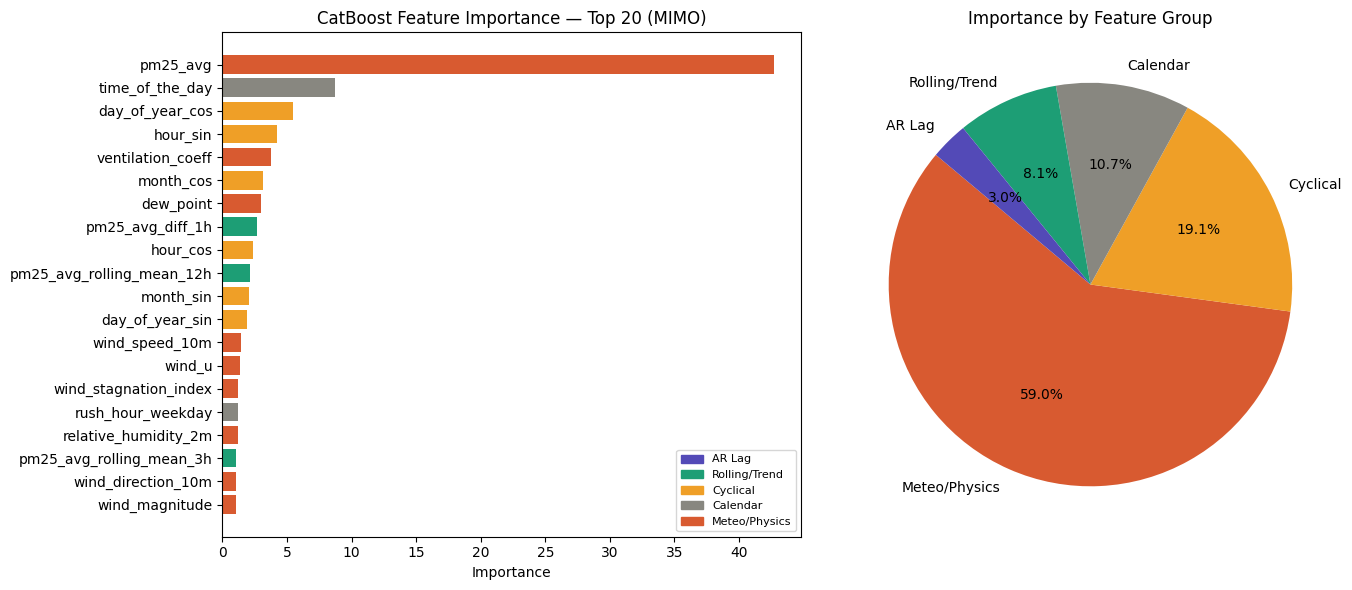

In [19]:
group_colors = {
    'AR Lag'        : '#534AB7',
    'Rolling/Trend' : '#1D9E75',
    'Cyclical'      : '#EF9F27',
    'Calendar'      : '#888780',
    'Meteo/Physics' : '#D85A30'
}

top20  = df_importance.head(20)
colors = [group_colors.get(g, '#aaa') for g in top20['group']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top20['feature'][::-1], top20['importance'][::-1], color=colors[::-1])
axes[0].set_title('CatBoost Feature Importance — Top 20 (MIMO)')
axes[0].set_xlabel('Importance')
from matplotlib.patches import Patch
axes[0].legend(
    handles=[Patch(color=c, label=g) for g, c in group_colors.items()],
    fontsize=8, loc='lower right'
)

axes[1].pie(
    df_group.values,
    labels=df_group.index,
    colors=[group_colors.get(g, '#aaa') for g in df_group.index],
    autopct='%1.1f%%', startangle=140
)
axes[1].set_title('Importance by Feature Group')

plt.tight_layout()
plt.savefig('mimo_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()